In [2]:
from google.colab import files
uploaded = files.upload()

Saving retail_customer_segmentation.csv to retail_customer_segmentation.csv


In [3]:
import pandas as pd

df = pd.read_csv('retail_customer_segmentation.csv')
print(df.head())

   customer_id  age  annual_income  months_active  avg_monthly_spend  \
0        33554   53  100473.211709             63         121.430565   
1         9428   54   54730.644845             67         572.552674   
2          200   44   58268.121079             57         266.593896   
3        12448   54   64829.795654             40         691.452358   
4        39490   28   27431.467873             15         832.664792   

   purchase_frequency  avg_order_value  discount_usage_rate  return_rate  \
0            0.817268        66.820403             0.117256     0.023144   
1            3.176551       137.087449             0.261647     0.429054   
2            2.713168        71.796888             0.284785     0.011854   
3            5.553977       105.501185             0.104832     0.399686   
4            1.348389       354.568534             0.409204     0.039517   

   browsing_time_minutes  support_interactions payment_method      region  \
0              77.298393         

In [4]:
import os
print(os.listdir())

['.config', 'retail_customer_segmentation.csv', 'sample_data']


In [5]:
print(df.dtypes)

customer_id                int64
age                        int64
annual_income            float64
months_active              int64
avg_monthly_spend        float64
purchase_frequency       float64
avg_order_value          float64
discount_usage_rate      float64
return_rate              float64
browsing_time_minutes    float64
support_interactions     float64
payment_method            object
region                    object
customer_segment          object
dtype: object


In [6]:
print(df.columns)

Index(['customer_id', 'age', 'annual_income', 'months_active',
       'avg_monthly_spend', 'purchase_frequency', 'avg_order_value',
       'discount_usage_rate', 'return_rate', 'browsing_time_minutes',
       'support_interactions', 'payment_method', 'region', 'customer_segment'],
      dtype='object')


In [7]:

# Numerical columns
numerical_cols = df.select_dtypes(include=['int64','float64']).columns

# Categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Numerical Attributes:")
print(list(numerical_cols))

print("\nCategorical Attributes:")
print(list(categorical_cols))

Numerical Attributes:
['customer_id', 'age', 'annual_income', 'months_active', 'avg_monthly_spend', 'purchase_frequency', 'avg_order_value', 'discount_usage_rate', 'return_rate', 'browsing_time_minutes', 'support_interactions']

Categorical Attributes:
['payment_method', 'region', 'customer_segment']


In [8]:
print(df.describe())

        customer_id           age  annual_income  months_active  \
count  50000.000000  50000.000000   46925.000000   50000.000000   
mean   25000.500000     44.002820   44542.620904      36.477480   
std    14433.901067     15.269871   30537.946035      20.787197   
min        1.000000     18.000000    2946.317892       1.000000   
25%    12500.750000     31.000000   24373.244554      18.000000   
50%    25000.500000     44.000000   36787.730010      36.000000   
75%    37500.250000     57.000000   55497.245522      55.000000   
max    50000.000000     70.000000  530788.317921      72.000000   

       avg_monthly_spend  purchase_frequency  avg_order_value  \
count       47480.000000        48021.000000     50000.000000   
mean          337.294238            4.910841        77.375915   
std           204.627095            3.416115        70.531793   
min             8.072298            0.017013         0.940393   
25%           192.074544            2.456867        32.018468   
50%   

In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            50000 non-null  int64  
 1   age                    50000 non-null  int64  
 2   annual_income          46925 non-null  float64
 3   months_active          50000 non-null  int64  
 4   avg_monthly_spend      47480 non-null  float64
 5   purchase_frequency     48021 non-null  float64
 6   avg_order_value        50000 non-null  float64
 7   discount_usage_rate    47451 non-null  float64
 8   return_rate            47513 non-null  float64
 9   browsing_time_minutes  46066 non-null  float64
 10  support_interactions   48012 non-null  float64
 11  payment_method         50000 non-null  object 
 12  region                 50000 non-null  object 
 13  customer_segment       50000 non-null  object 
dtypes: float64(8), int64(3), object(3)
memory usage: 5.3+ 

In [10]:
print(df.shape)

(50000, 14)


In [11]:
print(df.isnull().sum())

customer_id                 0
age                         0
annual_income            3075
months_active               0
avg_monthly_spend        2520
purchase_frequency       1979
avg_order_value             0
discount_usage_rate      2549
return_rate              2487
browsing_time_minutes    3934
support_interactions     1988
payment_method              0
region                      0
customer_segment            0
dtype: int64


In [12]:
df.fillna(df.median(numeric_only=True), inplace=True)

print(df.isnull().sum())

customer_id              0
age                      0
annual_income            0
months_active            0
avg_monthly_spend        0
purchase_frequency       0
avg_order_value          0
discount_usage_rate      0
return_rate              0
browsing_time_minutes    0
support_interactions     0
payment_method           0
region                   0
customer_segment         0
dtype: int64


In [13]:
print("Duplicate records before removal:", df.duplicated().sum())

Duplicate records before removal: 0


In [14]:
df.drop_duplicates(inplace=True)
print("Duplicate Records after removal:", df.duplicated().sum())

Duplicate Records after removal: 0


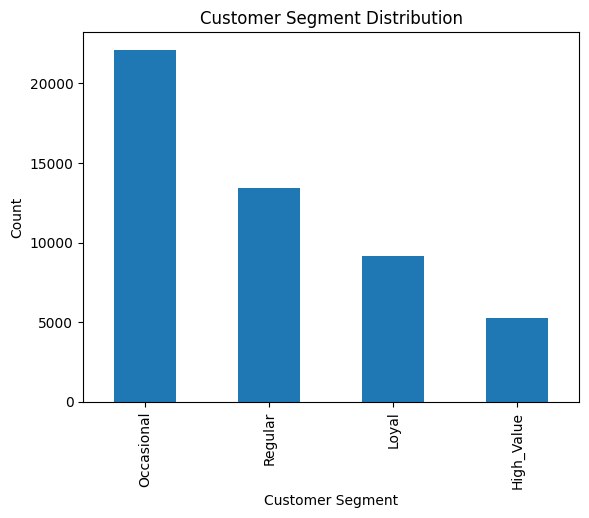

In [15]:
import matplotlib.pyplot as plt

df['customer_segment'].value_counts().plot(kind='bar')

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Count")

plt.show()

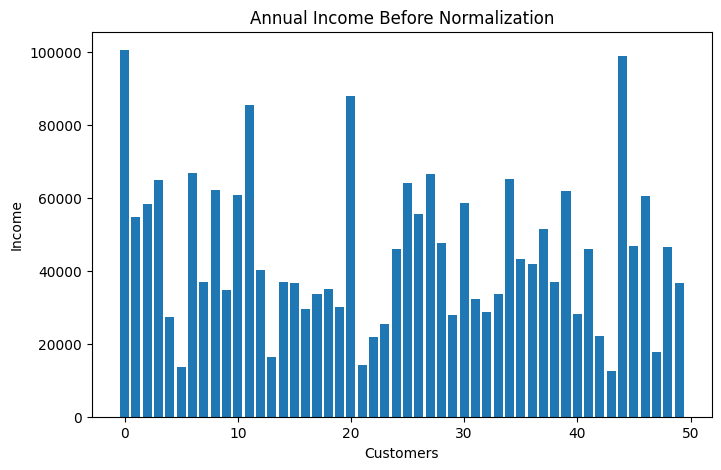

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(range(50), df['annual_income'][:50])
plt.title("Annual Income Before Normalization")
plt.xlabel("Customers")
plt.ylabel("Income")
plt.show()

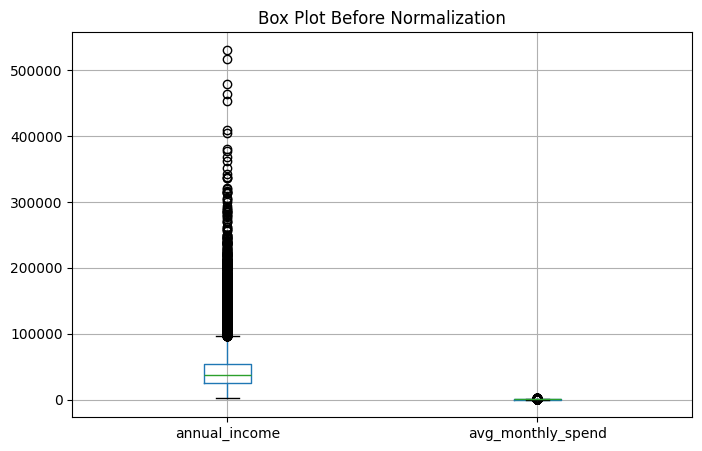

In [17]:
plt.figure(figsize=(8,5))

df[['annual_income', 'avg_monthly_spend']].boxplot()

plt.title("Box Plot Before Normalization")

plt.show()

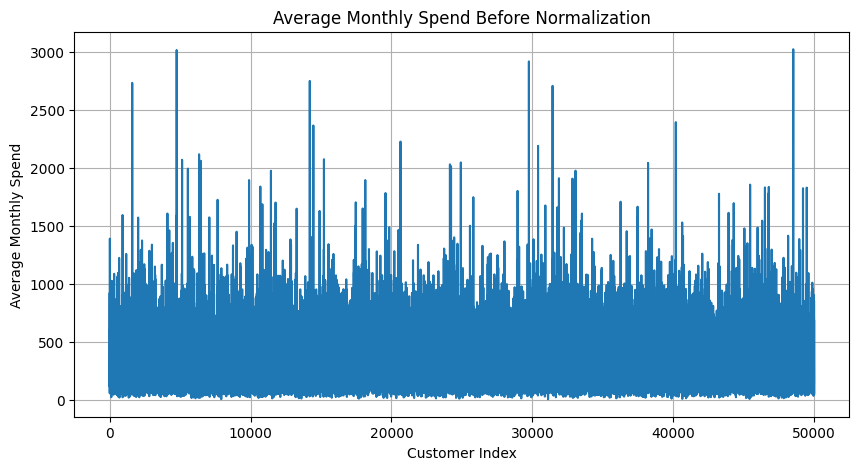

In [18]:
plt.figure(figsize=(10,5))

plt.plot(df['avg_monthly_spend'])

plt.title("Average Monthly Spend Before Normalization")
plt.xlabel("Customer Index")
plt.ylabel("Average Monthly Spend")
plt.grid(True)

plt.show()

In [19]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

In [20]:

numerical_cols = [
    'age',
    'annual_income',
    'months_active',
    'avg_monthly_spend',
    'purchase_frequency',
    'avg_order_value',
    'discount_usage_rate',
    'return_rate',
    'browsing_time_minutes',
    'support_interactions'
]

# Create MinMaxScaler object
minmax_scaler = MinMaxScaler()

# Create a copy of the dataset
df_minmax = df.copy()

# Apply Min-Max Normalization
df_minmax[numerical_cols] = minmax_scaler.fit_transform(df[numerical_cols])

# Compare original and normalized values
comparison = pd.DataFrame({
    'Original_Income': df['annual_income'],
    'Normalized_Income': df_minmax['annual_income']
})
print(comparison.head(10))

   Original_Income  Normalized_Income
0    100473.211709           0.184765
1     54730.644845           0.098106
2     58268.121079           0.104808
3     64829.795654           0.117239
4     27431.467873           0.046387
5     13511.061644           0.020015
6     66876.743284           0.121117
7     36787.730010           0.064113
8     62195.525423           0.112248
9     34685.254336           0.060130


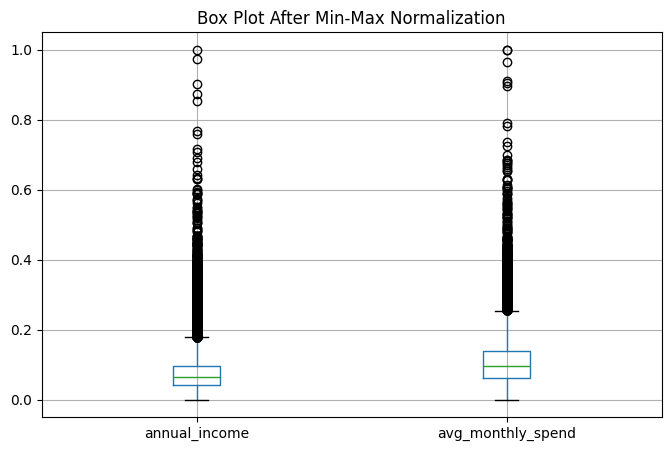

In [21]:
plt.figure(figsize=(8,5))

df_minmax[['annual_income','avg_monthly_spend']].boxplot()

plt.title("Box Plot After Min-Max Normalization")

plt.show()

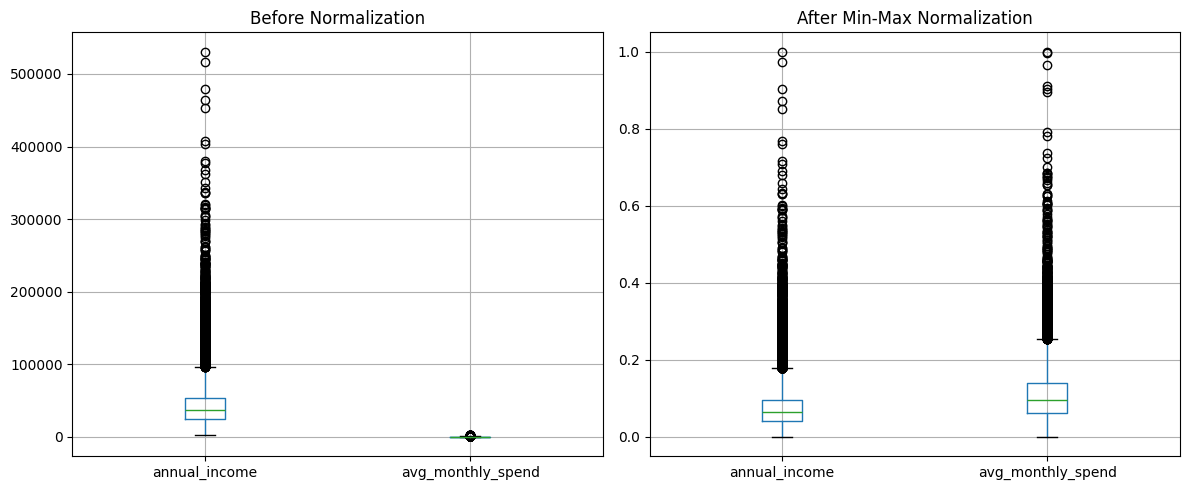

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

df[['annual_income','avg_monthly_spend']].boxplot(ax=ax[0])
ax[0].set_title('Before Normalization')

df_minmax[['annual_income','avg_monthly_spend']].boxplot(ax=ax[1])
ax[1].set_title('After Min-Max Normalization')

plt.tight_layout()
plt.show()

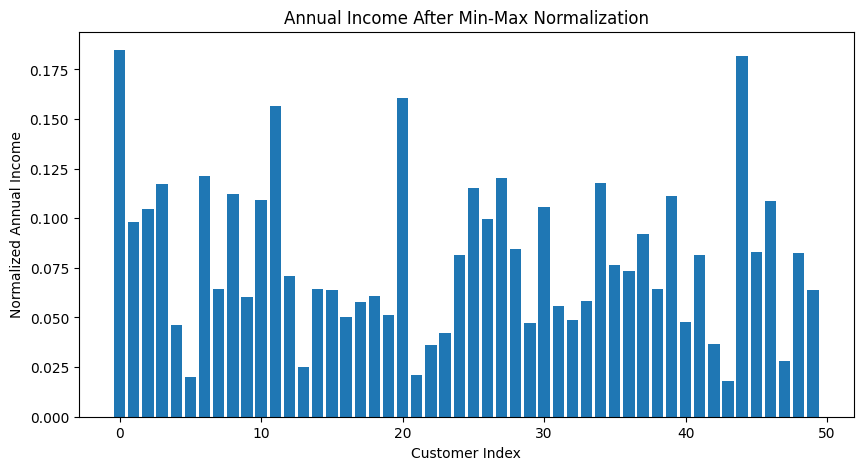

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(range(50), df_minmax['annual_income'][:50])

plt.title("Annual Income After Min-Max Normalization")
plt.xlabel("Customer Index")
plt.ylabel("Normalized Annual Income")
plt.show()

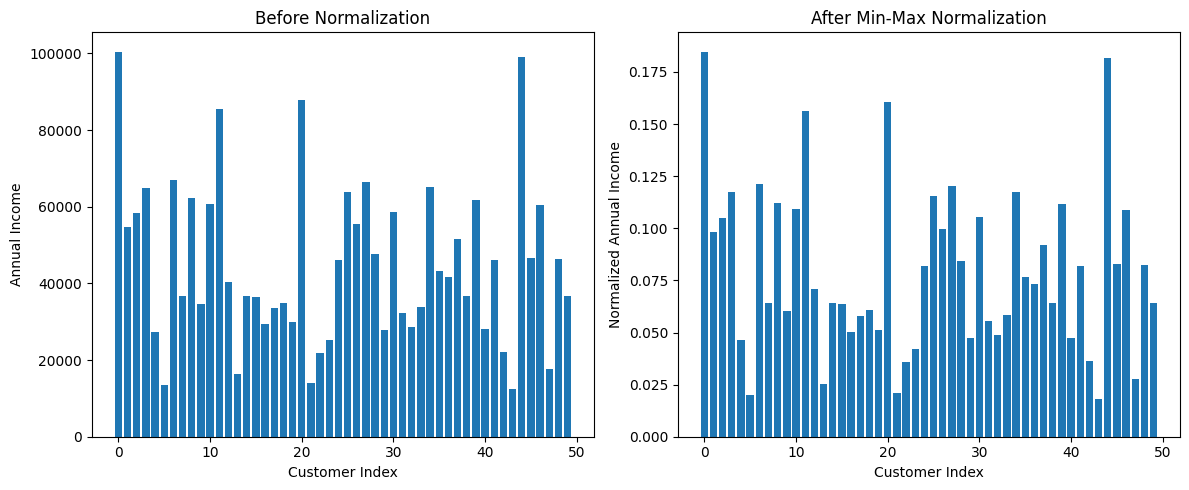

In [24]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12,5))

# Before Normalization
ax[0].bar(range(50), df['annual_income'][:50])
ax[0].set_title("Before Normalization")
ax[0].set_xlabel("Customer Index")
ax[0].set_ylabel("Annual Income")

# After Min-Max Normalization
ax[1].bar(range(50), df_minmax['annual_income'][:50])
ax[1].set_title("After Min-Max Normalization")
ax[1].set_xlabel("Customer Index")
ax[1].set_ylabel("Normalized Annual Income")

plt.tight_layout()
plt.show()

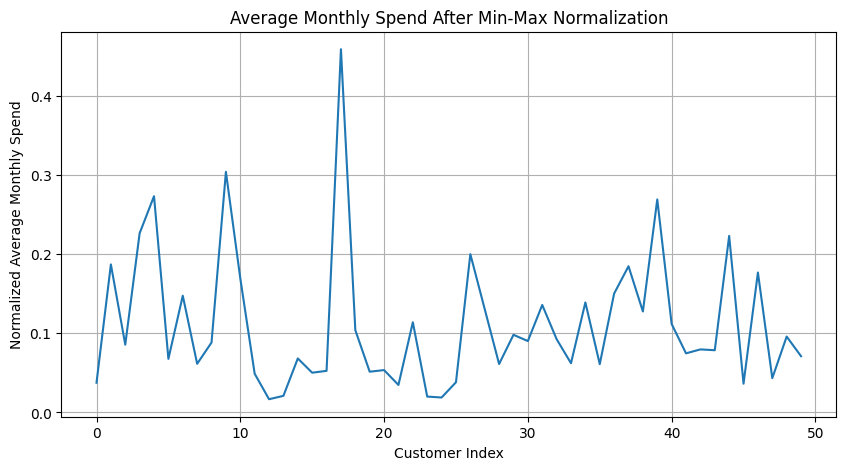

In [25]:
plt.figure(figsize=(10,5))

plt.plot(df_minmax['avg_monthly_spend'][:50])

plt.title("Average Monthly Spend After Min-Max Normalization")
plt.xlabel("Customer Index")
plt.ylabel("Normalized Average Monthly Spend")
plt.grid(True)

plt.show()

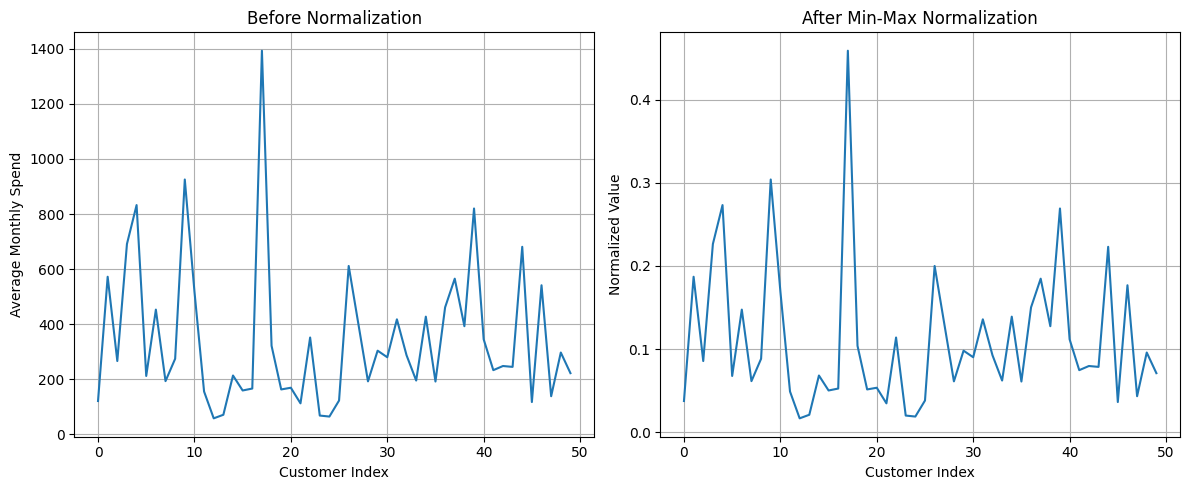

In [26]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12,5))

# Before Normalization
ax[0].plot(df['avg_monthly_spend'][:50])
ax[0].set_title("Before Normalization")
ax[0].set_xlabel("Customer Index")
ax[0].set_ylabel("Average Monthly Spend")
ax[0].grid(True)

# After Min-Max Normalization
ax[1].plot(df_minmax['avg_monthly_spend'][:50])
ax[1].set_title("After Min-Max Normalization")
ax[1].set_xlabel("Customer Index")
ax[1].set_ylabel("Normalized Value")
ax[1].grid(True)

plt.tight_layout()
plt.show()

In [27]:
from sklearn.preprocessing import StandardScaler

# Create StandardScaler object
zscore_scaler = StandardScaler()

# Create a copy of the dataset
df_zscore = df.copy()

# Apply Z-Score Normalization
df_zscore[numerical_cols] = zscore_scaler.fit_transform(df[numerical_cols])

# Display transformed values
print(df_zscore[numerical_cols].head())

        age  annual_income  months_active  avg_monthly_spend  \
0  0.589217       1.902940       1.275919          -1.071471   
1  0.654706       0.359788       1.468347           1.188752   
2 -0.000185       0.479127       0.987277          -0.344170   
3  0.654706       0.700489       0.169458           1.784466   
4 -1.048010      -0.561165      -1.033217           2.491972   

   purchase_frequency  avg_order_value  discount_usage_rate  return_rate  \
0           -1.212712        -0.149658            -1.069563    -1.154784   
1           -0.508660         0.846599            -0.139189     2.608367   
2           -0.646941        -0.079100             0.009899    -1.259453   
3            0.200808         0.398764            -1.149617     2.336104   
4           -1.054216         3.930077             0.811588    -1.002994   

   browsing_time_minutes  support_interactions  
0               0.404395              0.437317  
1               0.773937              0.437317  
2          

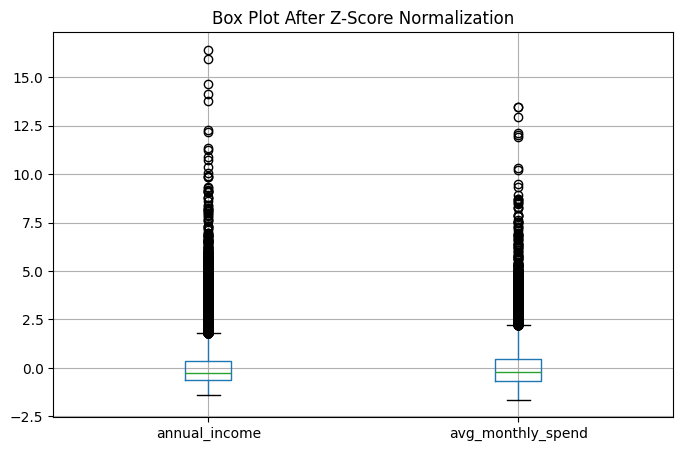

In [28]:
plt.figure(figsize=(8,5))

df_zscore[['annual_income','avg_monthly_spend']].boxplot()

plt.title("Box Plot After Z-Score Normalization")

plt.show()

/tmp/ipykernel_4609/3880766892.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[0].boxplot([
/tmp/ipykernel_4609/3880766892.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1].boxplot([


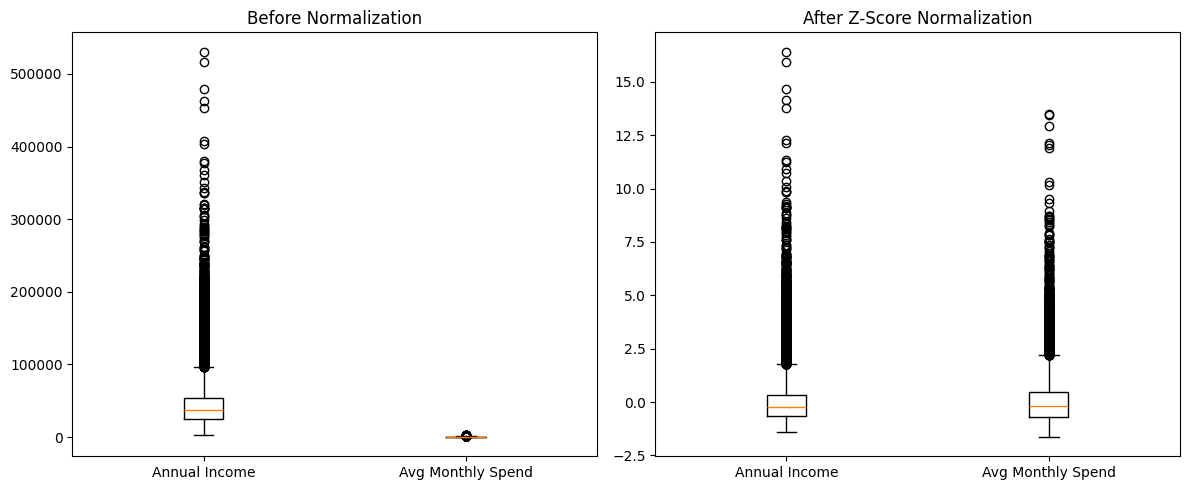

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

# Before Normalization
ax[0].boxplot([
    df['annual_income'],
    df['avg_monthly_spend']
], labels=['Annual Income', 'Avg Monthly Spend'])
ax[0].set_title("Before Normalization")

# After Z-Score Normalization
ax[1].boxplot([
    df_zscore['annual_income'],
    df_zscore['avg_monthly_spend']
], labels=['Annual Income', 'Avg Monthly Spend'])
ax[1].set_title("After Z-Score Normalization")

plt.tight_layout()
plt.show()

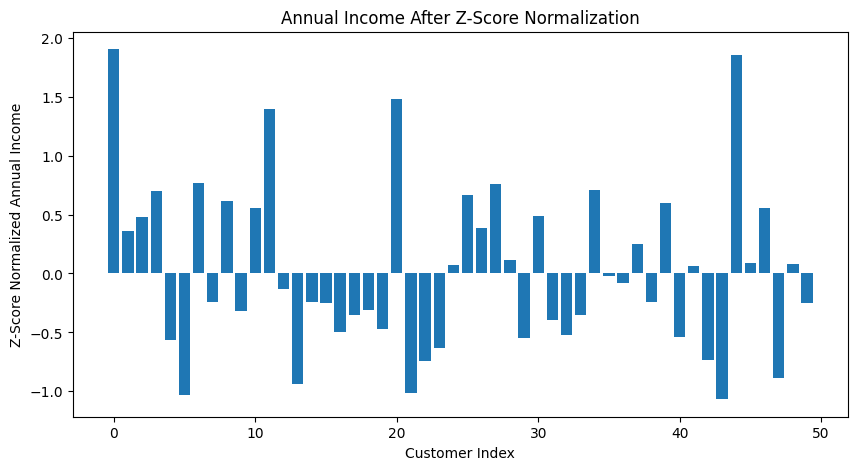

In [30]:
plt.figure(figsize=(10,5))

plt.bar(range(50), df_zscore['annual_income'][:50])

plt.title("Annual Income After Z-Score Normalization")
plt.xlabel("Customer Index")
plt.ylabel("Z-Score Normalized Annual Income")

plt.show()

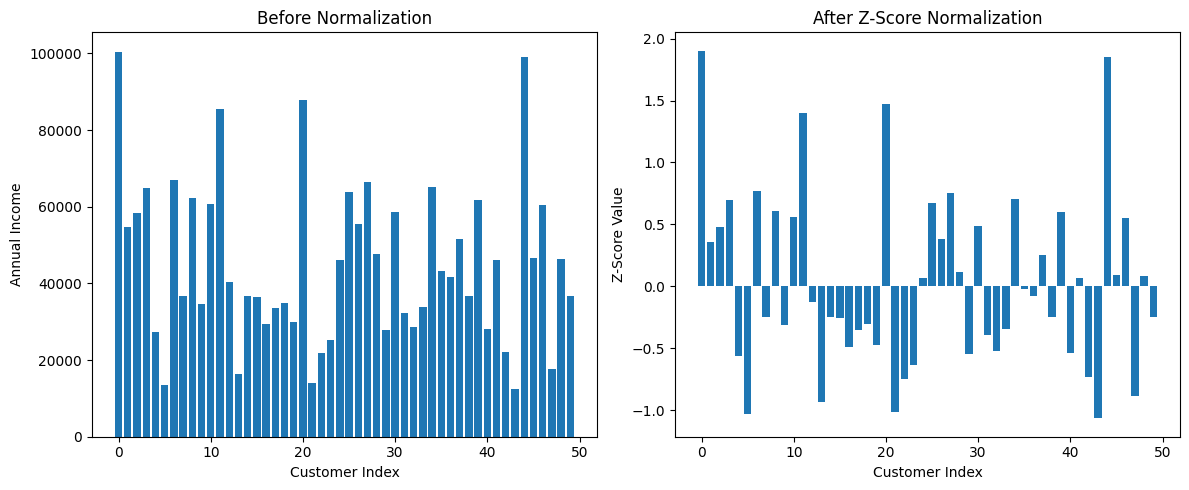

In [31]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12,5))

# Before Normalization
ax[0].bar(range(50), df['annual_income'][:50])
ax[0].set_title("Before Normalization")
ax[0].set_xlabel("Customer Index")
ax[0].set_ylabel("Annual Income")

# After Z-Score Normalization
ax[1].bar(range(50), df_zscore['annual_income'][:50])
ax[1].set_title("After Z-Score Normalization")
ax[1].set_xlabel("Customer Index")
ax[1].set_ylabel("Z-Score Value")

plt.tight_layout()
plt.show()

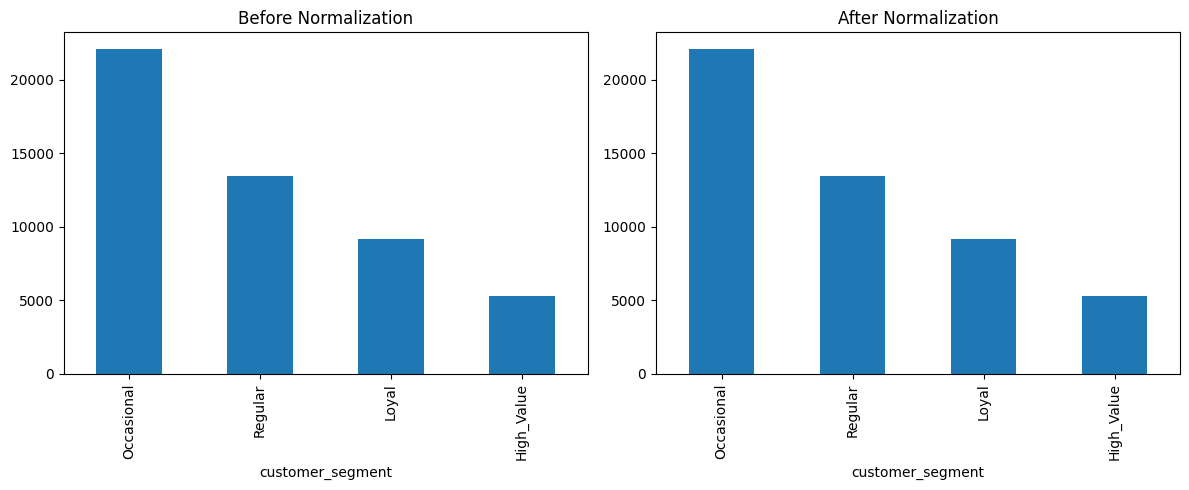

In [32]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12,5))

df['customer_segment'].value_counts().plot(kind='bar', ax=ax[0])
ax[0].set_title('Before Normalization')

df['customer_segment'].value_counts().plot(kind='bar', ax=ax[1])
ax[1].set_title('After Normalization')

plt.tight_layout()
plt.show()

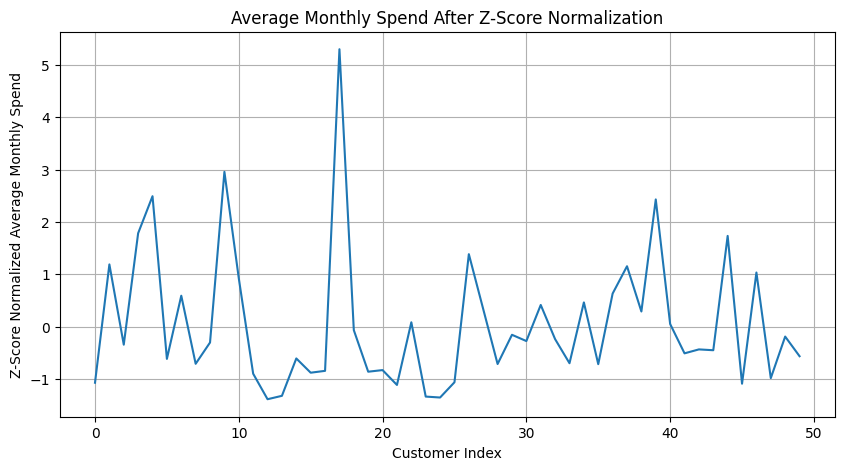

In [33]:
plt.figure(figsize=(10,5))

plt.plot(df_zscore['avg_monthly_spend'][:50])

plt.title("Average Monthly Spend After Z-Score Normalization")
plt.xlabel("Customer Index")
plt.ylabel("Z-Score Normalized Average Monthly Spend")
plt.grid(True)

plt.show()

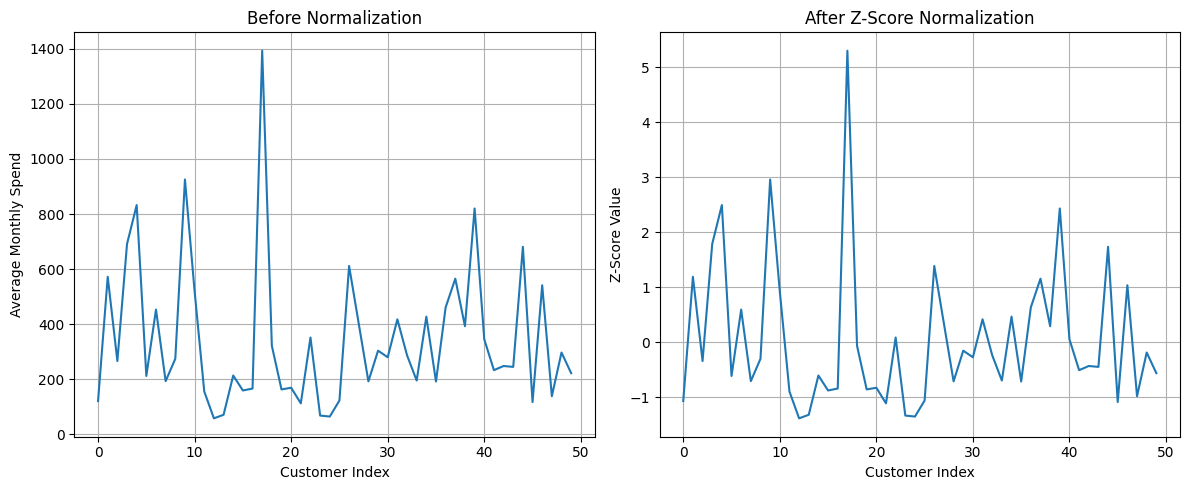

In [34]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

# Before Normalization
ax[0].plot(df['avg_monthly_spend'][:50])
ax[0].set_title("Before Normalization")
ax[0].set_xlabel("Customer Index")
ax[0].set_ylabel("Average Monthly Spend")
ax[0].grid(True)

# After Z-Score Normalization
ax[1].plot(df_zscore['avg_monthly_spend'][:50])
ax[1].set_title("After Z-Score Normalization")
ax[1].set_xlabel("Customer Index")
ax[1].set_ylabel("Z-Score Value")
ax[1].grid(True)

plt.tight_layout()
plt.show()

In [35]:
print("Original Data")
print(df[['annual_income','avg_monthly_spend']].head())

print("\nMin-Max Normalized Data")
print(df_minmax[['annual_income','avg_monthly_spend']].head())

print("\nZ-Score Normalized Data")
print(df_zscore[['annual_income','avg_monthly_spend']].head())

Original Data
   annual_income  avg_monthly_spend
0  100473.211709         121.430565
1   54730.644845         572.552674
2   58268.121079         266.593896
3   64829.795654         691.452358
4   27431.467873         832.664792

Min-Max Normalized Data
   annual_income  avg_monthly_spend
0       0.184765           0.037557
1       0.098106           0.187021
2       0.104808           0.085652
3       0.117239           0.226414
4       0.046387           0.273200

Z-Score Normalized Data
   annual_income  avg_monthly_spend
0       1.902940          -1.071471
1       0.359788           1.188752
2       0.479127          -0.344170
3       0.700489           1.784466
4      -0.561165           2.491972


In [36]:
print("Original Dataset Statistics")
print(df[['annual_income','avg_monthly_spend']].describe())

print("\nMin-Max Statistics")
print(df_minmax[['annual_income','avg_monthly_spend']].describe())

print("\nZ-Score Statistics")
print(df_zscore[['annual_income','avg_monthly_spend']].describe())

Original Dataset Statistics
       annual_income  avg_monthly_spend
count   50000.000000       50000.000000
mean    44065.695114         335.287469
std     29642.592692         199.593893
min      2946.317892           8.072298
25%     25112.704208         197.220824
50%     36787.730010         297.477404
75%     53830.215138         429.191654
max    530788.317921        3026.342238

Min-Max Statistics
       annual_income  avg_monthly_spend
count   50000.000000       50000.000000
mean        0.077901           0.108411
std         0.056158           0.066129
min         0.000000           0.000000
25%         0.041994           0.062668
50%         0.064113           0.095884
75%         0.096400           0.139523
max         1.000000           1.000000

Z-Score Statistics
       annual_income  avg_monthly_spend
count   5.000000e+04       5.000000e+04
mean    3.227285e-16       3.680611e-16
std     1.000010e+00       1.000010e+00
min    -1.387186e+00      -1.639421e+00
25%    -6.39

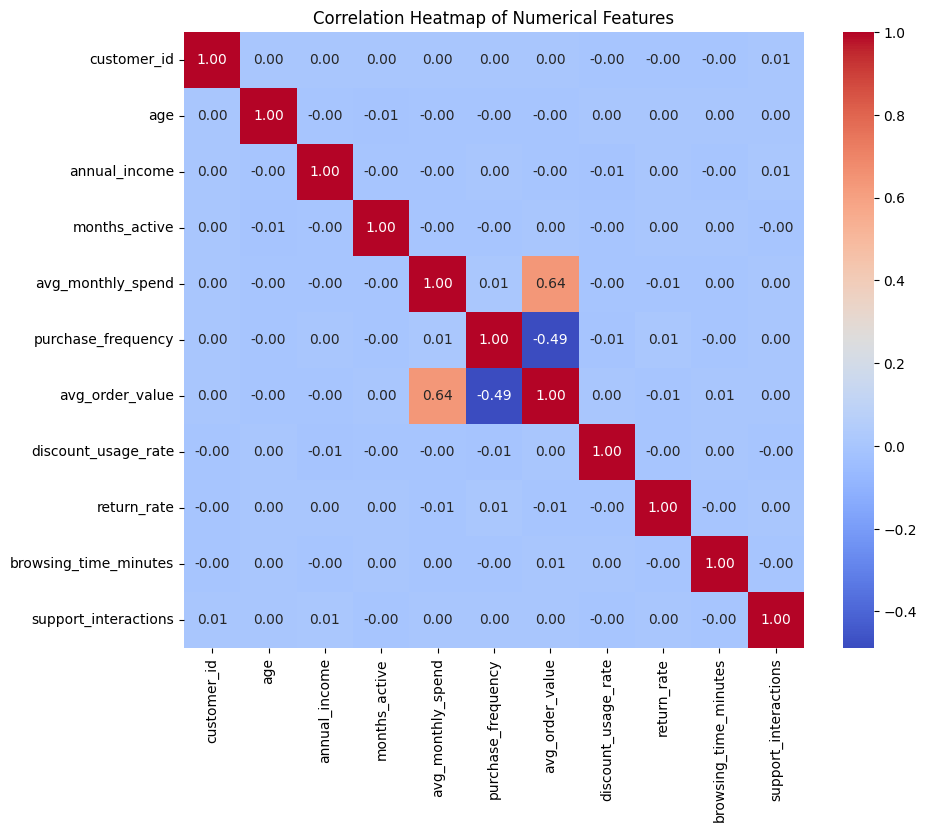

In [37]:

import seaborn as sns

# Select only numerical columns
numerical_df = df.select_dtypes(include=['int64', 'float64'])

# Create correlation matrix
corr_matrix = numerical_df.corr()

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

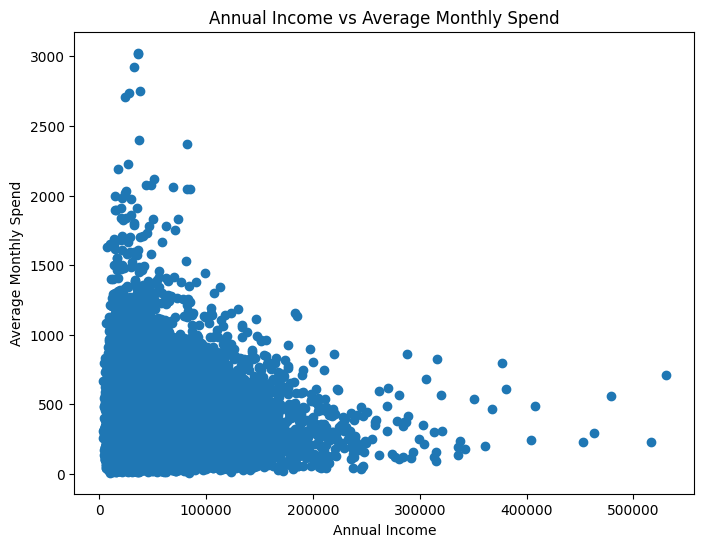

In [38]:

plt.figure(figsize=(8,6))

plt.scatter(df['annual_income'], df['avg_monthly_spend'])

plt.title("Annual Income vs Average Monthly Spend")
plt.xlabel("Annual Income")
plt.ylabel("Average Monthly Spend")

plt.show()